<a href="https://colab.research.google.com/github/sudarshanyakkanti-coder/loan-prediction/blob/main/Smart_Lender_Loan_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving loan_prediction.csv to loan_prediction (1).csv


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import os
print(os.listdir())

['.config', 'loan_prediction (1).csv', 'loan_prediction.csv', 'sample_data']


In [ ]:
df = pd.read_csv("loan_prediction.csv")

In [ ]:
df.head()


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
df.shape

(614, 13)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [ ]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [ ]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [ ]:
cat_cols = ['Gender', 'Married', 'Dependents', 'Self_Employed']

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
num_cols = ['LoanAmount', 'Loan_Amount_Term', 'Credit_History']

for col in num_cols:
    df[col] = df[col].fillna(df[col].mean())

In [ ]:
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_columns = ['Gender', 'Married', 'Dependents',
                       'Education', 'Self_Employed',
                       'Property_Area', 'Loan_Status']

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1,0,0,0,0,5849,0.0,146.412162,360.0,1.0,2,1
1,LP001003,1,1,1,0,0,4583,1508.0,128.000000,360.0,1.0,0,0
2,LP001005,1,1,0,0,1,3000,0.0,66.000000,360.0,1.0,2,1
3,LP001006,1,1,0,1,0,2583,2358.0,120.000000,360.0,1.0,2,1
4,LP001008,1,0,0,0,0,6000,0.0,141.000000,360.0,1.0,2,1


In [ ]:
df = df.drop("Loan_ID", axis=1)

df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,146.412162,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.000000,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.000000,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.000000,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.000000,360.0,1.0,2,1


In [ ]:
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]


In [ ]:
print(X.shape)
print(y.shape)

(614, 11)
(614,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(491, 11)
(123, 11)


In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
y_pred = model.predict(X_test)

print(y_pred)

[1 0 1 0 1 1 1 1 1 0 0 1 1 0 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 0 0 1
 1 1 1 1 1 1 1 1 1 1 0 0 0 0 1 0 0 1 1 1 0 0 1 0 1 0 0 1 1 1 1 1 1 0 1 1 1
 0 1 1 1 0 1 0 1 1 0 1 1 1 0 1 1 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 0 1 0 1 1 0
 0 1 1 0 0 1 1 0 0 0 1 1]


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7154471544715447


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[23 20]
 [15 65]]


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.61      0.53      0.57        43
           1       0.76      0.81      0.79        80

    accuracy                           0.72       123
   macro avg       0.68      0.67      0.68       123
weighted avg       0.71      0.72      0.71       123



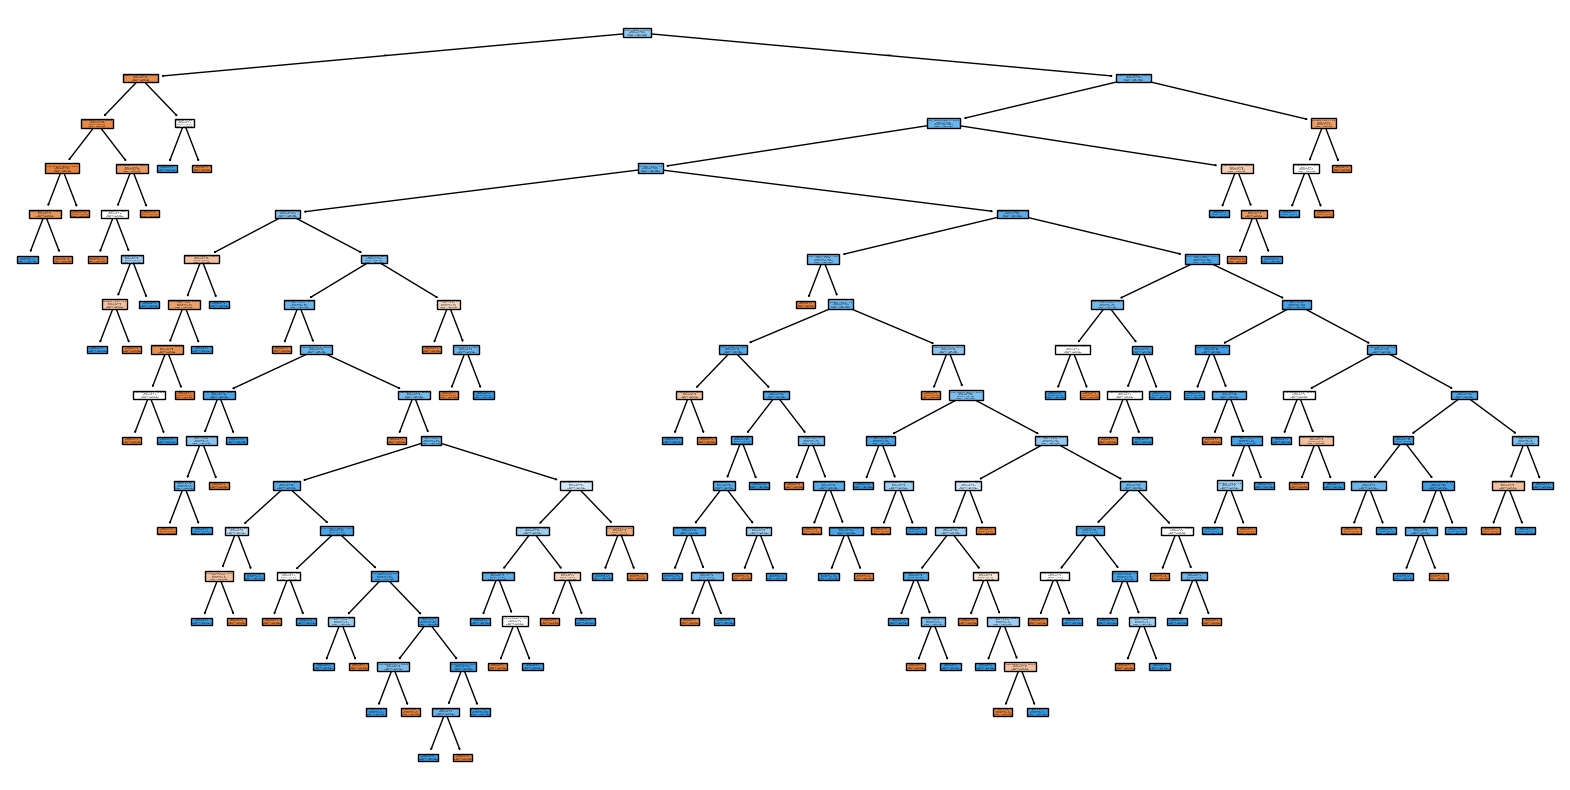

In [ ]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
tree.plot_tree(
    model,
    feature_names=X.columns,
    class_names=['Rejected', 'Approved'],
    filled=True
)
plt.show()

In [ ]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)

print(importance)

              Feature  Importance
9      Credit_History    0.321530
5     ApplicantIncome    0.214155
7          LoanAmount    0.211750
6   CoapplicantIncome    0.096681
8    Loan_Amount_Term    0.041221
10      Property_Area    0.038902
2          Dependents    0.034881
1             Married    0.018144
3           Education    0.011291
4       Self_Employed    0.007494
0              Gender    0.003952


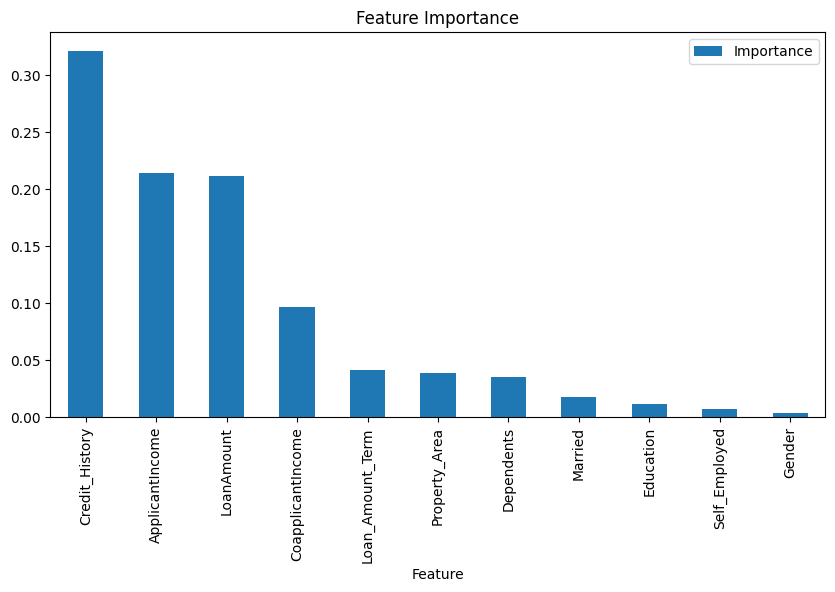

In [ ]:
import matplotlib.pyplot as plt

importance.plot(x='Feature', y='Importance', kind='bar', figsize=(10,5))
plt.title("Feature Importance")
plt.show()

Conclusion:

The loan prediction dataset was successfully cleaned and preprocessed.
Missing values were handled and categorical variables were encoded.
The dataset was split into training and testing sets.
A Decision Tree Classifier was trained to predict loan approval status.
The model was evaluated using accuracy, a confusion matrix, and a classification report.
The trained model can be used to predict whether a loan application is likely to be approved based on applicant details.